In [32]:
import sys
sys.path.append("../src")

In [33]:
from db_connection import DatabaseConnector
from queries import NBAReceiverQuaries
from data_loader import NBADataLoader
from statistical_tests import StatisticalTester
from effect_size import EffectSizeCalculator
from confidence_interval import ConfidenceIntervalCalculator
from descriptive_statistics import DescriptiveStatistics


In [34]:
db = DatabaseConnector(env_path="../.env")
engine = db.create_connection()


In [35]:
loader = NBADataLoader(engine)

df_agility = loader.load_agility_data(NBAReceiverQuaries.query_agility)
df_intrinsic = loader.load_intrinsic_data(NBAReceiverQuaries.query_intrinsic)


In [36]:
df_agility.head()


,season_years,period_group,player_id,fullname,agility
0,2020-2021,past_period,1036,Stephen Curry,0.400000
1,2020-2021,past_period,2561,Damian Lillard,0.370000
2,2020-2021,past_period,120,Giannis Antetokounmpo,0.341564
3,2020-2021,past_period,1480,Julius Randle,0.324000
4,2020-2021,past_period,3935,Joel Embiid,0.300000


In [37]:
df_agility.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   season_years  41 non-null     str    
 1   period_group  41 non-null     str    
 2   player_id     41 non-null     int64  
 3   fullname      41 non-null     str    
 4   agility       41 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 1.7 KB


In [38]:
df_intrinsic.head()

,season_years,period_group,champion_club,player_id,fullname,age,experience,intrinsic_talent
0,2020-2021,past_period,Atlanta Hawks,727,Clint Capela,26.0,6,0.230769
1,2020-2021,past_period,Atlanta Hawks,898,John Collins,23.0,3,0.130435
2,2020-2021,past_period,Atlanta Hawks,3845,Kris Dunn,26.0,4,0.153846
3,2020-2021,past_period,Atlanta Hawks,4013,Bruno Fernando,22.0,1,0.045455
4,2020-2021,past_period,Atlanta Hawks,3205,Kevin Huerter,22.0,2,0.090909


In [39]:
df_intrinsic.info()

<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season_years      182 non-null    str    
 1   period_group      182 non-null    str    
 2   champion_club     182 non-null    str    
 3   player_id         182 non-null    int64  
 4   fullname          182 non-null    str    
 5   age               182 non-null    float64
 6   experience        182 non-null    int64  
 7   intrinsic_talent  182 non-null    float64
dtypes: float64(2), int64(2), str(4)
memory usage: 11.5 KB


In [40]:
tester = StatisticalTester(alpha=0.05)

results = []


In [41]:
agility_result = tester.run_hypothesis_test(
    df=df_agility,
    value_column="agility",
    hypothesis_name="Agility of Top 20 MVP Candidates",
    group_column="period_group"
)

In [42]:
tester.print_report(agility_result)

Hypothesis Test Report: Agility of Top 20 MVP Candidates

Value Column:
agility

Sample Sizes:
Past period: 23
Recent period: 18

Means:
Past mean: 0.35874697154208784
Recent mean: 0.3669407438782334
Mean difference: 0.008193772336145544

Normality Test - Past Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9610091173742892), 'p_value': np.float64(0.4840469030421829), 'is_normal': np.True_}

Normality Test - Recent Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9072326045430256), 'p_value': np.float64(0.07690352308312025), 'is_normal': np.True_}

Selected Test:
welch

Test Result:
{'test': 'Welch independent t-test', 'alternative': 'recent > past', 'statistic': np.float64(0.7564315021749917), 'p_value': np.float64(0.2270579994043617), 'is_significant': np.False_}

Description:
از آنجا که مقدار p-value برابر با 0.2271 است و از سطح معناداری alpha = 0.05 بزرگ‌تر یا مساوی می‌باشد، فرض صفر رد نمی‌شود.
بنابراین شواهد آماری کافی وجود ندارد که نتیجه بگیریم مقدار متغیر مو

In [43]:
agility_past = df_agility[
    df_agility["period_group"] == "past_period"
]["agility"]

agility_recent = df_agility[
    df_agility["period_group"] == "recent_period"
]["agility"]


agility_effect = EffectSizeCalculator.calculate_cohens_d(
    agility_past,
    agility_recent
)

print(agility_effect)

{'method': "Cohen's d", 'effect_size': -0.23648412206323405, 'absolute_effect_size': 0.23648412206323405, 'interpretation': 'Small Effect', 'group1_size': 23, 'group2_size': 18}


In [44]:
agility_ci = ConfidenceIntervalCalculator.mean_difference_ci(
    df_agility[
        df_agility["period_group"] == "past_period"
    ]["agility"],

    df_agility[
        df_agility["period_group"] == "recent_period"
    ]["agility"]
)

print(agility_ci)

{'method': 'Mean Difference Confidence Interval', 'confidence_level': 0.95, 'mean_difference': -0.008193772336145544, 'lower_bound': -0.030131789185469333, 'upper_bound': 0.013744244513178246, 'sample_size_group1': 23, 'sample_size_group2': 18}


In [45]:
recent_agility = df_agility[
    df_agility["period_group"] == "recent_period"
]["agility"]


past_agility = df_agility[
    df_agility["period_group"] == "past_period"
]["agility"]

In [1]:
recent_summary = DescriptiveStatistics.summarize(
    recent_agility
)

past_summary = DescriptiveStatistics.summarize(
    past_agility
)

NameError: name 'DescriptiveStatistics' is not defined

In [47]:
recent_summary

{'sample_size': 18,
 'mean': 0.3669407438782334,
 'std': 0.03361067005756401,
 'min': 0.3,
 'q1': 0.3415895061728395,
 'median': 0.36339285714285713,
 'q3': 0.3973684210526316,
 'max': 0.42528735632183906}

In [48]:
past_summary

{'sample_size': 23,
 'mean': 0.35874697154208784,
 'std': 0.035429293374538554,
 'min': 0.3,
 'q1': 0.3355105751746579,
 'median': 0.35,
 'q3': 0.38047619047619047,
 'max': 0.42528735632183906}

In [49]:
intrinsic_result = tester.run_hypothesis_test(
    df=df_intrinsic,
    value_column="intrinsic_talent",
    hypothesis_name="Comparison of intrinsic talent between players of past and recent periods",
    group_column="period_group"
)

In [50]:
tester.print_report(intrinsic_result)

Hypothesis Test Report: Comparison of intrinsic talent between players of past and recent periods

Value Column:
intrinsic_talent

Sample Sizes:
Past period: 72
Recent period: 110

Means:
Past mean: 0.16233394210178834
Recent mean: 0.20830947442313213
Mean difference: 0.0459755323213438

Normality Test - Past Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9005309493791748), 'p_value': np.float64(3.213795703750859e-05), 'is_normal': np.False_}

Normality Test - Recent Period:
{'test': 'Shapiro-Wilk', 'statistic': np.float64(0.9369473361203006), 'p_value': np.float64(5.742119210619375e-05), 'is_normal': np.False_}

Selected Test:
mannwhitney

Test Result:
{'test': 'Mann-Whitney U test', 'alternative': 'recent > past', 'statistic': np.float64(4862.0), 'p_value': np.float64(0.00473278882258946), 'is_significant': np.True_}

Description:
از آنجا که مقدار p-value برابر با 0.0047 است و از سطح معناداری alpha = 0.05 کمتر می‌باشد، فرض صفر رد می‌شود.
بنابراین شواهد آماری معناداری وجود

In [51]:
intrinsic_effect = EffectSizeCalculator.calculate_cohens_d(
    df_intrinsic[df_intrinsic["period_group"] == "past_period"]["intrinsic_talent"],
    df_intrinsic[df_intrinsic["period_group"] == "recent_period"]["intrinsic_talent"]
)

print(intrinsic_effect)

{'method': "Cohen's d", 'effect_size': -0.404713250500258, 'absolute_effect_size': 0.404713250500258, 'interpretation': 'Small Effect', 'group1_size': 72, 'group2_size': 110}


In [52]:
intrinsic_ci = ConfidenceIntervalCalculator.mean_difference_ci(
    df_intrinsic[
        df_intrinsic["period_group"] == "past_period"
    ]["intrinsic_talent"],

    df_intrinsic[
        df_intrinsic["period_group"] == "recent_period"
    ]["intrinsic_talent"]
)

print(intrinsic_ci)

{'method': 'Mean Difference Confidence Interval', 'confidence_level': 0.95, 'mean_difference': -0.0459755323213438, 'lower_bound': -0.07883938428045066, 'upper_bound': -0.013111680362236935, 'sample_size_group1': 72, 'sample_size_group2': 110}


In [53]:
effect_intrinsic = EffectSizeCalculator.calculate_cohens_d(
    df_intrinsic[
        df_intrinsic["period_group"] == "recent_period"
    ]["intrinsic_talent"],

    df_intrinsic[
        df_intrinsic["period_group"] == "past_period"
    ]["intrinsic_talent"]
)

effect_intrinsic

{'method': "Cohen's d",
 'effect_size': 0.404713250500258,
 'absolute_effect_size': 0.404713250500258,
 'interpretation': 'Small Effect',
 'group1_size': 110,
 'group2_size': 72}

In [54]:
ci_intrinsic = ConfidenceIntervalCalculator.mean_difference_ci(
    df_intrinsic[
        df_intrinsic["period_group"] == "recent_period"
    ]["intrinsic_talent"],

    df_intrinsic[
        df_intrinsic["period_group"] == "past_period"
    ]["intrinsic_talent"]
)

ci_intrinsic

{'method': 'Mean Difference Confidence Interval',
 'confidence_level': 0.95,
 'mean_difference': 0.0459755323213438,
 'lower_bound': 0.013111680362236935,
 'upper_bound': 0.07883938428045066,
 'sample_size_group1': 110,
 'sample_size_group2': 72}

In [55]:
effect_intrinsic = EffectSizeCalculator.calculate_cohens_d(
    df_intrinsic[df_intrinsic["period_group"]=="recent_period"]["intrinsic_talent"],
    df_intrinsic[df_intrinsic["period_group"]=="past_period"]["intrinsic_talent"]
)

ci_intrinsic = ConfidenceIntervalCalculator.mean_difference_ci(
    df_intrinsic[df_intrinsic["period_group"]=="recent_period"]["intrinsic_talent"],
    df_intrinsic[df_intrinsic["period_group"]=="past_period"]["intrinsic_talent"]
)

print(effect_intrinsic)
print(ci_intrinsic)

{'method': "Cohen's d", 'effect_size': 0.404713250500258, 'absolute_effect_size': 0.404713250500258, 'interpretation': 'Small Effect', 'group1_size': 110, 'group2_size': 72}
{'method': 'Mean Difference Confidence Interval', 'confidence_level': 0.95, 'mean_difference': 0.0459755323213438, 'lower_bound': 0.013111680362236935, 'upper_bound': 0.07883938428045066, 'sample_size_group1': 110, 'sample_size_group2': 72}


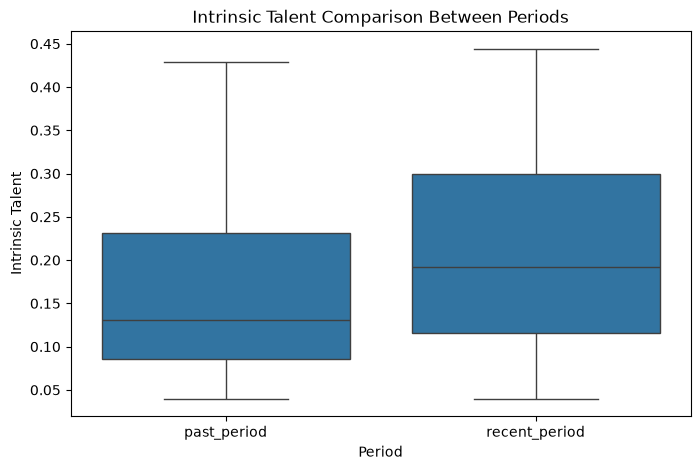

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_intrinsic,
    x="period_group",
    y="intrinsic_talent"
)

plt.title(
    "Intrinsic Talent Comparison Between Periods"
)

plt.xlabel("Period")
plt.ylabel("Intrinsic Talent")

plt.show()

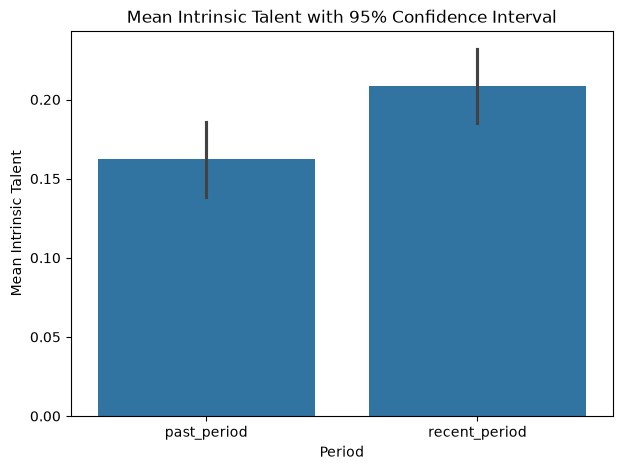

In [60]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_intrinsic,
    x="period_group",
    y="intrinsic_talent",
    errorbar="ci"
)

plt.title(
    "Mean Intrinsic Talent with 95% Confidence Interval"
)

plt.xlabel("Period")
plt.ylabel("Mean Intrinsic Talent")

plt.show()

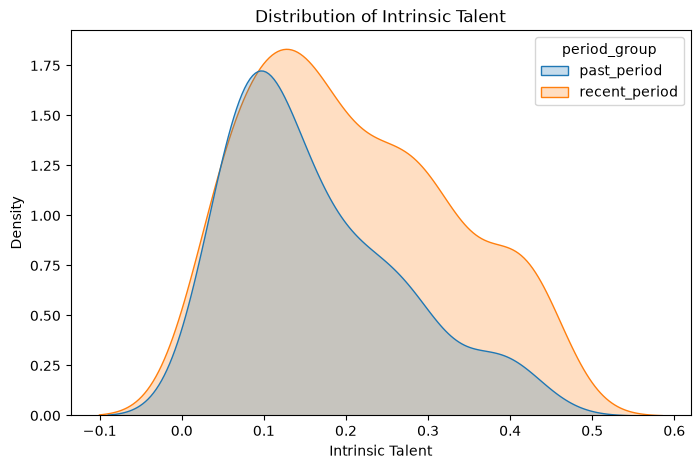

In [61]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_intrinsic,
    x="intrinsic_talent",
    hue="period_group",
    fill=True
)

plt.title(
    "Distribution of Intrinsic Talent"
)

plt.xlabel("Intrinsic Talent")

plt.show()

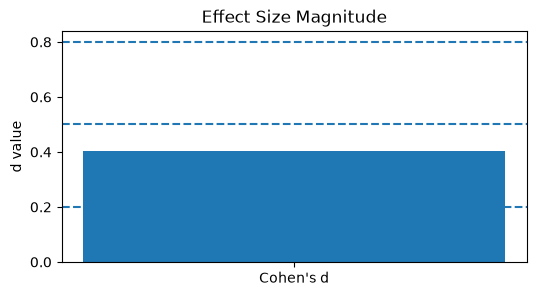

In [62]:
effect = effect_intrinsic["absolute_effect_size"]

plt.figure(figsize=(6,3))

plt.bar(
    ["Cohen's d"],
    [effect]
)

plt.axhline(
    0.2,
    linestyle="--"
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.axhline(
    0.8,
    linestyle="--"
)

plt.title(
    "Effect Size Magnitude"
)

plt.ylabel("d value")

plt.show()